---
## A — The Overfitting Problem

Recall from Polynomial Regression: a high-degree model fits training data perfectly but tanks on test data.

**Why does that happen?**
The model learns **huge weights** to wiggle through every training point — including the noise.
Those giant weights make it hypersensitive and useless on unseen data.

**The fix: penalize large weights.**
We add a penalty to the loss function that says:
> *"You can't just care about fitting the training data — you also have to keep weights small."*

This is **Regularization**. It forces the model to stay humble.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)

# Create a dataset: y = sin(x) + noise  — clearly non-linear
X_raw = np.sort(5 * np.random.rand(80))
y_raw = np.sin(X_raw) + np.random.randn(80) * 0.3

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw.reshape(-1, 1), y_raw, test_size=0.2, random_state=0
)

print(f"Train size: {len(X_tr)}, Test size: {len(X_te)}")
print("Data: y = sin(x) + noise")

Train size: 64, Test size: 16
Data: y = sin(x) + noise


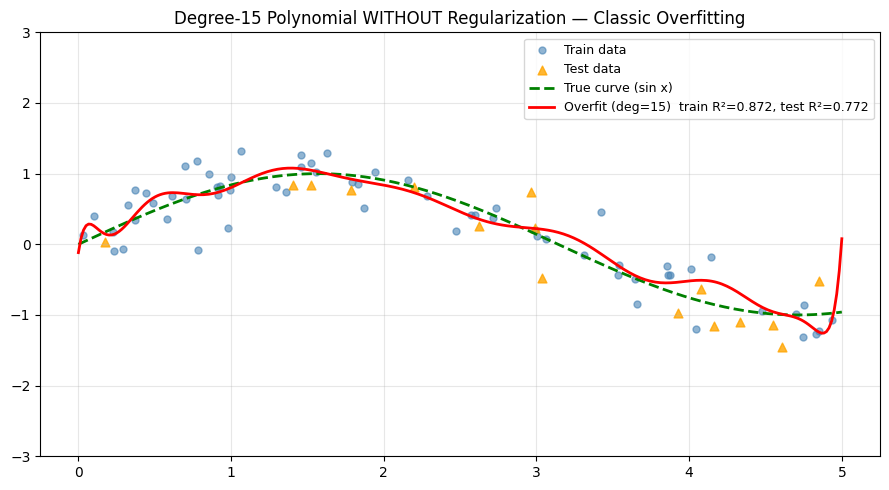

Train R²: 0.8717
Test  R²: 0.7715  ← massive gap = overfitting


In [4]:
# Demonstrate overfitting with degree-15 polynomial (no regularization)
def make_pipeline(model, degree=15):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('model',  model)
    ])

overfit_pipe = make_pipeline(LinearRegression(), degree=15)
overfit_pipe.fit(X_tr, y_tr)

X_plot = np.linspace(0, 5, 300).reshape(-1, 1)
y_overfit = overfit_pipe.predict(X_plot)

train_r2 = r2_score(y_tr, overfit_pipe.predict(X_tr))
test_r2  = r2_score(y_te, overfit_pipe.predict(X_te))

plt.figure(figsize=(9, 5))
plt.scatter(X_tr, y_tr, alpha=0.6, color='steelblue', s=25, label='Train data')
plt.scatter(X_te, y_te, alpha=0.8, color='orange',    s=40, marker='^', label='Test data')
plt.plot(X_plot, np.sin(X_plot), 'g--', linewidth=2, label='True curve (sin x)')
plt.plot(X_plot, y_overfit, 'r-', linewidth=2, label=f'Overfit (deg=15)  train R²={train_r2:.3f}, test R²={test_r2:.3f}')
plt.ylim(-3, 3)
plt.title("Degree-15 Polynomial WITHOUT Regularization — Classic Overfitting")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}  ← massive gap = overfitting")

---
## B — Ridge Regression (L2 Regularization)

Ridge adds the **sum of squared weights** to the loss function:

$$\text{Ridge Loss} = \underbrace{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}_{\text{MSE}} + \underbrace{\alpha \sum_{j} w_j^2}_{\text{L2 penalty}}$$

- $\alpha$ (alpha) = how hard we push weights toward zero
  - $\alpha = 0$ → plain Linear Regression
  - $\alpha \to \infty$ → all weights → 0 (useless model)
  - **Just right $\alpha$** → shrinks weights, prevents overfitting

**Key property:** Ridge **shrinks** all weights but rarely zeroes them out completely. It keeps all features in the model, just with smaller coefficients.

---
## C — Lasso Regression (L1 Regularization)

Lasso adds the **sum of absolute weights** instead:

$$\text{Lasso Loss} = \frac{1}{n}\sum (y_i - \hat{y}_i)^2 + \alpha \sum_{j} |w_j|$$

**Key difference from Ridge:**
Lasso can push weights to **exactly zero** — it performs **automatic feature selection**.

If you have 100 features and only 10 matter, Lasso will zero out the 90 irrelevant ones.

| | Ridge (L2) | Lasso (L1) |
|-|------------|------------|
| Penalty | $\sum w_j^2$ | $\sum \|w_j\|$ |
| Effect | Shrinks weights | Zeros out weights |
| Feature selection | No | **Yes** |
| Use when | All features matter (roughly) | Many irrelevant features |

---
## D — The Math: Closed-Form for Ridge

Ridge has an elegant closed-form solution (Lasso doesn't — it needs iterative solvers):

$$\mathbf{w}_{ridge} = (\mathbf{X}^T \mathbf{X} + \alpha \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

The $\alpha \mathbf{I}$ term adds $\alpha$ to the diagonal of $\mathbf{X}^T \mathbf{X}$. This:
1. Makes the matrix always invertible (fixes numerical instability when features are correlated)
2. Shrinks the learned weights proportional to $\alpha$

This is why Ridge is also called **Tikhonov regularization** in the math world.

---
## E — Ridge From Scratch (NumPy)

Implementing the closed-form Ridge solution directly.

In [5]:
class RidgeFromScratch:
    """Ridge Regression using the closed-form solution."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.w = None

    def fit(self, X, y):
        # Add bias column (column of ones)
        X_b = np.column_stack([np.ones(len(X)), X])
        n_features = X_b.shape[1]

        # w = (X^T X + alpha * I)^-1 X^T y
        # (don't penalize the bias term — set its diagonal entry to 0)
        penalty = self.alpha * np.eye(n_features)
        penalty[0, 0] = 0  # don't regularize bias

        self.w = np.linalg.solve(X_b.T @ X_b + penalty, X_b.T @ y)
        return self

    def predict(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        return X_b @ self.w

# Simple 2-feature test
# Create polynomial features first (degree=3), then apply Ridge
scaler = StandardScaler()
pf = PolynomialFeatures(degree=15, include_bias=False)

X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled  = scaler.transform(X_te)
X_tr_poly = pf.fit_transform(X_tr_scaled)
X_te_poly  = pf.transform(X_te_scaled)

ridge_scratch = RidgeFromScratch(alpha=10.0)
ridge_scratch.fit(X_tr_poly, y_tr)

train_r2 = r2_score(y_tr, ridge_scratch.predict(X_tr_poly))
test_r2  = r2_score(y_te, ridge_scratch.predict(X_te_poly))

print(f"Ridge Scratch — Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
print(f"Weight magnitudes (first 5): {np.abs(ridge_scratch.w[1:6]).round(3)}")
print("Compare with overfit weights below...")

Ridge Scratch — Train R²: 0.8204  |  Test R²: 0.7923
Weight magnitudes (first 5): [0.293 0.135 0.13  0.12  0.062]
Compare with overfit weights below...


---
## F — Sklearn: Ridge, Lasso, ElasticNet

Same `make_pipeline` helper — just swap the model.

c:\Users\dammi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.228e+00, tolerance: 3.286e-03
  model = cd_fast.enet_coordinate_descent(


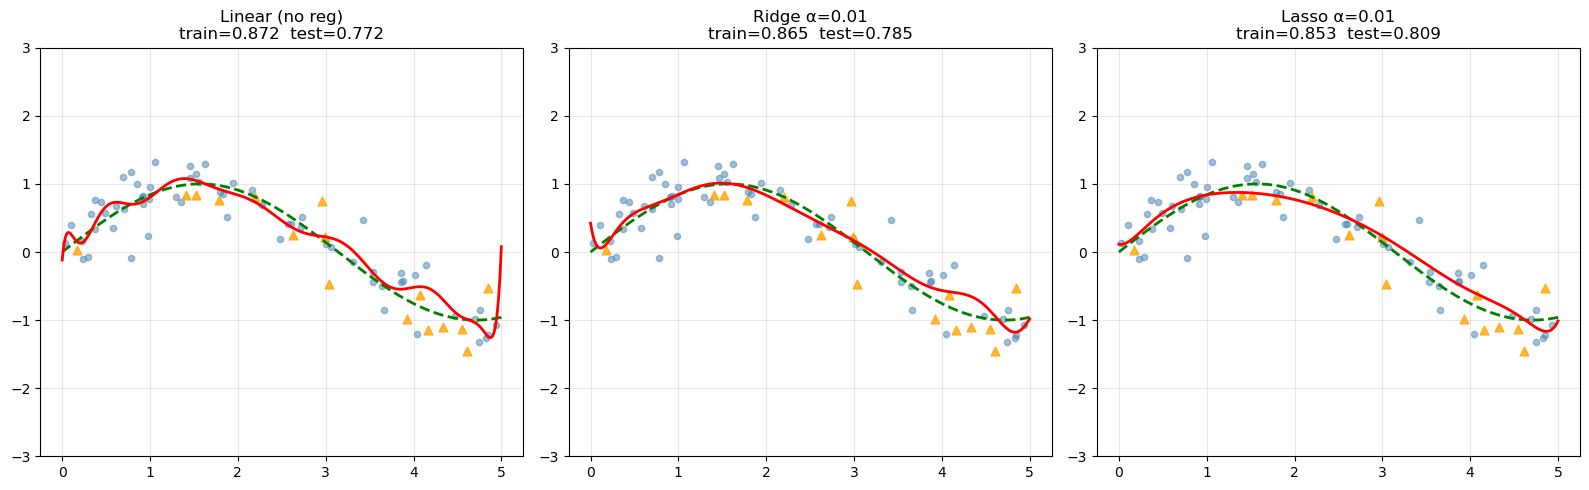

In [4]:
def build_pipe(model, degree=15):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('model',  model)
    ])

ALPHA = 0.01
models = {
    'Linear (no reg)':  build_pipe(LinearRegression()),
    f'Ridge α={ALPHA}': build_pipe(Ridge(alpha=ALPHA)),
    f'Lasso α={ALPHA}': build_pipe(Lasso(alpha=ALPHA, max_iter=10000)),
}

X_plot = np.linspace(0, 5, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pipe) in zip(axes, models.items()):
    pipe.fit(X_tr, y_tr)
    y_plot = pipe.predict(X_plot)
    tr2 = r2_score(y_tr, pipe.predict(X_tr))
    te2 = r2_score(y_te, pipe.predict(X_te))

    ax.scatter(X_tr, y_tr, alpha=0.5, color='steelblue', s=20)
    ax.scatter(X_te, y_te, alpha=0.8, color='orange', s=40, marker='^')
    ax.plot(X_plot, np.sin(X_plot), 'g--', linewidth=2, label='True')
    clipped = np.clip(y_plot, -3, 3)
    ax.plot(X_plot, clipped, 'r-', linewidth=2)
    ax.set_ylim(-3, 3)
    ax.set_title(f"{name}\ntrain={tr2:.3f}  test={te2:.3f}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## G — Choosing Alpha: Regularization Path

Alpha is a hyperparameter — we don't learn it from data, we tune it.

**Strategy:** try many values of $\alpha$, pick the one with the best test/CV score.

This is called the **regularization path**.

c:\Users\dammi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.276e+00, tolerance: 3.286e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\dammi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.270e+00, tolerance: 3.286e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\dammi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.263e+00, toleranc

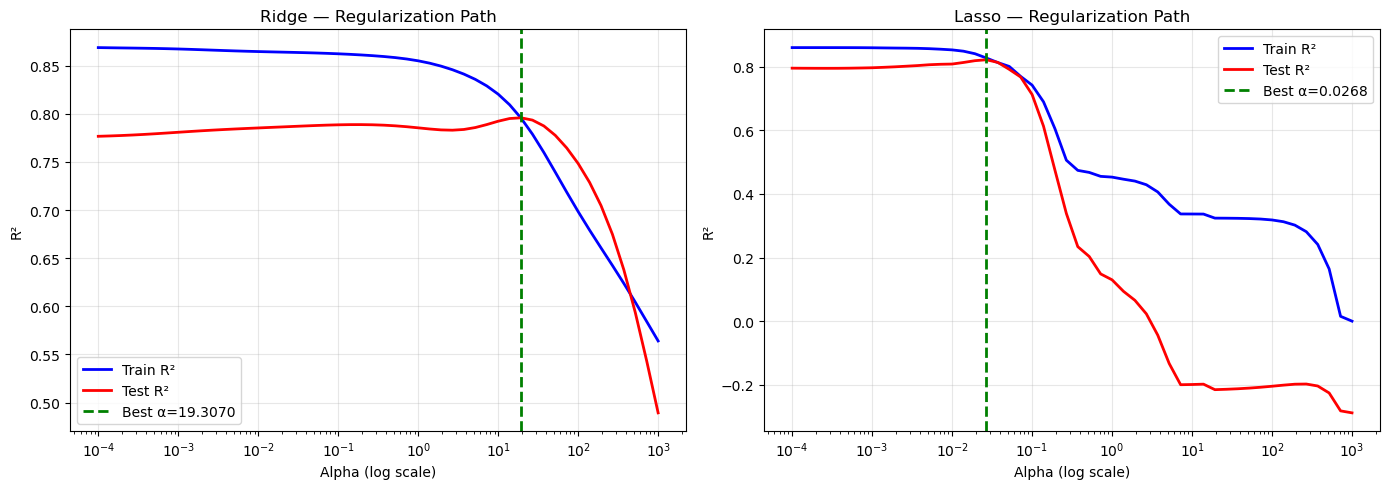

Best Ridge alpha: 19.30698  → Test R²: 0.7958
Best Lasso alpha: 0.02683  → Test R²: 0.8223


In [8]:
alphas = np.logspace(-4, 3, 50)   # 0.0001 to 1000, log scale

ridge_train, ridge_test = [], []
lasso_train, lasso_test = [], []

for a in alphas:
    r_pipe = build_pipe(Ridge(alpha=a))
    l_pipe = build_pipe(Lasso(alpha=a, max_iter=10000))

    r_pipe.fit(X_tr, y_tr); l_pipe.fit(X_tr, y_tr)
    ridge_train.append(r2_score(y_tr, r_pipe.predict(X_tr)))
    ridge_test.append(r2_score(y_te, r_pipe.predict(X_te)))
    lasso_train.append(r2_score(y_tr, l_pipe.predict(X_tr)))
    lasso_test.append(r2_score(y_te, l_pipe.predict(X_te)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tr, te, title) in zip(axes, [
    (ridge_train, ridge_test, 'Ridge'),
    (lasso_train, lasso_test, 'Lasso')
]):
    ax.semilogx(alphas, tr, 'b-', linewidth=2, label='Train R²')
    ax.semilogx(alphas, te, 'r-', linewidth=2, label='Test R²')
    best_a = alphas[np.argmax(te)]
    ax.axvline(best_a, color='green', linestyle='--', linewidth=2, label=f'Best α={best_a:.4f}')
    ax.set_xlabel("Alpha (log scale)")
    ax.set_ylabel("R²")
    ax.set_title(f"{title} — Regularization Path")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Ridge alpha: {alphas[np.argmax(ridge_test)]:.5f}  → Test R²: {max(ridge_test):.4f}")
print(f"Best Lasso alpha: {alphas[np.argmax(lasso_test)]:.5f}  → Test R²: {max(lasso_test):.4f}")

---
## H — Ridge vs Lasso: Weight Sparsity

The clearest difference between Ridge and Lasso is **what happens to individual weights.**

Let's visualize the weight magnitudes side-by-side for the same alpha.

c:\Users\dammi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.228e+00, tolerance: 3.286e-03
  model = cd_fast.enet_coordinate_descent(


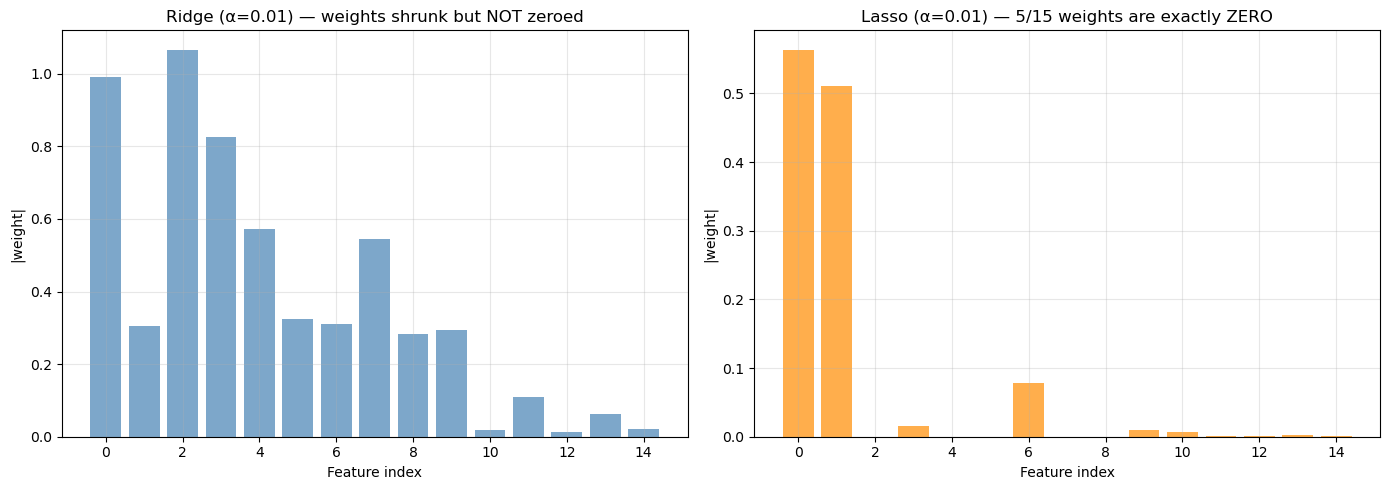

Ridge: 0 zero weights out of 15
Lasso: 5 zero weights out of 15  ← automatic feature selection!


In [6]:
COMPARE_ALPHA = 0.01

ridge_pipe = build_pipe(Ridge(alpha=COMPARE_ALPHA))
lasso_pipe = build_pipe(Lasso(alpha=COMPARE_ALPHA, max_iter=10000))

ridge_pipe.fit(X_tr, y_tr)
lasso_pipe.fit(X_tr, y_tr)

ridge_coefs = ridge_pipe.named_steps['model'].coef_
lasso_coefs = lasso_pipe.named_steps['model'].coef_
n_features = len(ridge_coefs)
feat_idx = np.arange(n_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(feat_idx, np.abs(ridge_coefs), color='steelblue', alpha=0.7)
axes[0].set_title(f"Ridge (α={COMPARE_ALPHA}) — weights shrunk but NOT zeroed")
axes[0].set_xlabel("Feature index")
axes[0].set_ylabel("|weight|")
axes[0].grid(True, alpha=0.3)

axes[1].bar(feat_idx, np.abs(lasso_coefs), color='darkorange', alpha=0.7)
n_zero = np.sum(lasso_coefs == 0)
axes[1].set_title(f"Lasso (α={COMPARE_ALPHA}) — {n_zero}/{n_features} weights are exactly ZERO")
axes[1].set_xlabel("Feature index")
axes[1].set_ylabel("|weight|")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ridge: {np.sum(ridge_coefs == 0)} zero weights out of {n_features}")
print(f"Lasso: {np.sum(lasso_coefs == 0)} zero weights out of {n_features}  ← automatic feature selection!")

---
## I — Elastic Net: Best of Both Worlds

Elastic Net combines L1 and L2:

$$\text{ElasticNet Loss} = MSE + \alpha \left[ \rho \sum|w_j| + \frac{(1-\rho)}{2} \sum w_j^2 \right]$$

Where $\rho$ (`l1_ratio` in sklearn) controls the mix:
- $\rho = 1$ → pure Lasso
- $\rho = 0$ → pure Ridge
- $0 < \rho < 1$ → Elastic Net

**When to use Elastic Net:** when you have many features and want some to be zeroed out (like Lasso) but also want Ridge's stability when features are correlated.

In [7]:
from sklearn.linear_model import ElasticNet

results = {}
for name, model in [
    ('Linear',        LinearRegression()),
    ('Ridge',         Ridge(alpha=0.01)),
    ('Lasso',         Lasso(alpha=0.01, max_iter=10000)),
    ('ElasticNet',    ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)),
]:
    pipe = build_pipe(model)
    pipe.fit(X_tr, y_tr)
    results[name] = {
        'train_r2': r2_score(y_tr, pipe.predict(X_tr)),
        'test_r2':  r2_score(y_te, pipe.predict(X_te)),
    }

print(f"{'Model':<15} {'Train R²':>10} {'Test R²':>10}")
print("-" * 37)
for name, vals in results.items():
    print(f"{name:<15} {vals['train_r2']:>10.4f} {vals['test_r2']:>10.4f}")

print()
print("All regularized models beat plain Linear Regression on test data.")

Model             Train R²    Test R²
-------------------------------------
Linear              0.8717     0.7715
Ridge               0.8646     0.7853
Lasso               0.8534     0.8088
ElasticNet          0.8551     0.8103

All regularized models beat plain Linear Regression on test data.


c:\Users\dammi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.228e+00, tolerance: 3.286e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\dammi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.449e+00, tolerance: 3.286e-03
  model = cd_fast.enet_coordinate_descent(


---
## 🏁 Summary

```
Overfitting → Large weights → Penalize weights → Ridge (shrink) or Lasso (zero out)
```

| What you learned | Key takeaway |
|-----------------|-------------|
| Overfitting | Big weights = memorized noise = fails on new data |
| Regularization | Add penalty to loss to keep weights small |
| Ridge (L2) | $\sum w_j^2$ penalty — shrinks all weights, keeps all features |
| Lasso (L1) | $\sum\|w_j\|$ penalty — zeros out irrelevant features (feature selection) |
| Closed form | Ridge: $(\mathbf{X}^T\mathbf{X} + \alpha\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$ |
| Alpha tuning | Log-scale search + plot regularization path |
| ElasticNet | Mix of L1 + L2 — use when features are correlated AND sparse |

### When to use what?
- **Ridge:** all features probably matter, multicollinearity present
- **Lasso:** many irrelevant features, want automatic feature selection
- **ElasticNet:** many features + some correlation between them

### What's Next?
- **Logistic Regression** — when you want to predict a CLASS, not a number